# ⚖️ Legal Intelligence System: Advanced Causal Dashboard
Developed by Antigravity AI Assistant

## 🎯 Objective
This dashboard provides deep-tissue analysis of 10,000 legal judgments. It visualizes the evidentiary pillars of success and failure using InLegalBERT and Statistical Machine Learning.

In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import faiss

# Set Styling
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (14, 8)
RESULTS_DIR = '/home/amaydixit11/Desktop/dev/Legal-Intelligence-System/results'

cluster_names = {
    'cluster_0': 'Medical/FSL', 'cluster_1': 'Witness Testimony', 'cluster_2': 'Agreements', 
    'cluster_3': 'Memos', 'cluster_4': 'FIR/PM Reports', 'cluster_5': 'Property Deeds'
}

## 📊 Section 1: The Corpus Breakdown
We scanned 9,703 judgments to identify the 5.1% 'Weak Case' subset (dismissed due to evidentiary failure).

In [2]:
with open(f'{RESULTS_DIR}/failed_cases_index.json', 'r') as f:
    weak_cases = json.load(f)

total_cases = 9703
plt.pie([total_cases-len(weak_cases), len(weak_cases)], 
        labels=['Strong/Success', 'Weak/Failed'], 
        autopct='%1.1f%%', startangle=140, colors=['#5D9C59', '#DF2E38'], explode=(0, 0.1))
plt.title('Legal Landscape: Evidentiary Success Rates')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/home/amaydixit11/Desktop/dev/Legal-Intelligence-System/results/failed_cases_index.json'

## 🧬 Section 2: Global Causal Ranking (Feature Importance)
Using a Random Forest model, we identify which evidence clusters have the highest weight in determining the final judgment outcome.

/tmp/ipykernel_52797/1312867471.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rank_df, x='Importance Score (%)', y='Evidence Cluster', palette='magma')


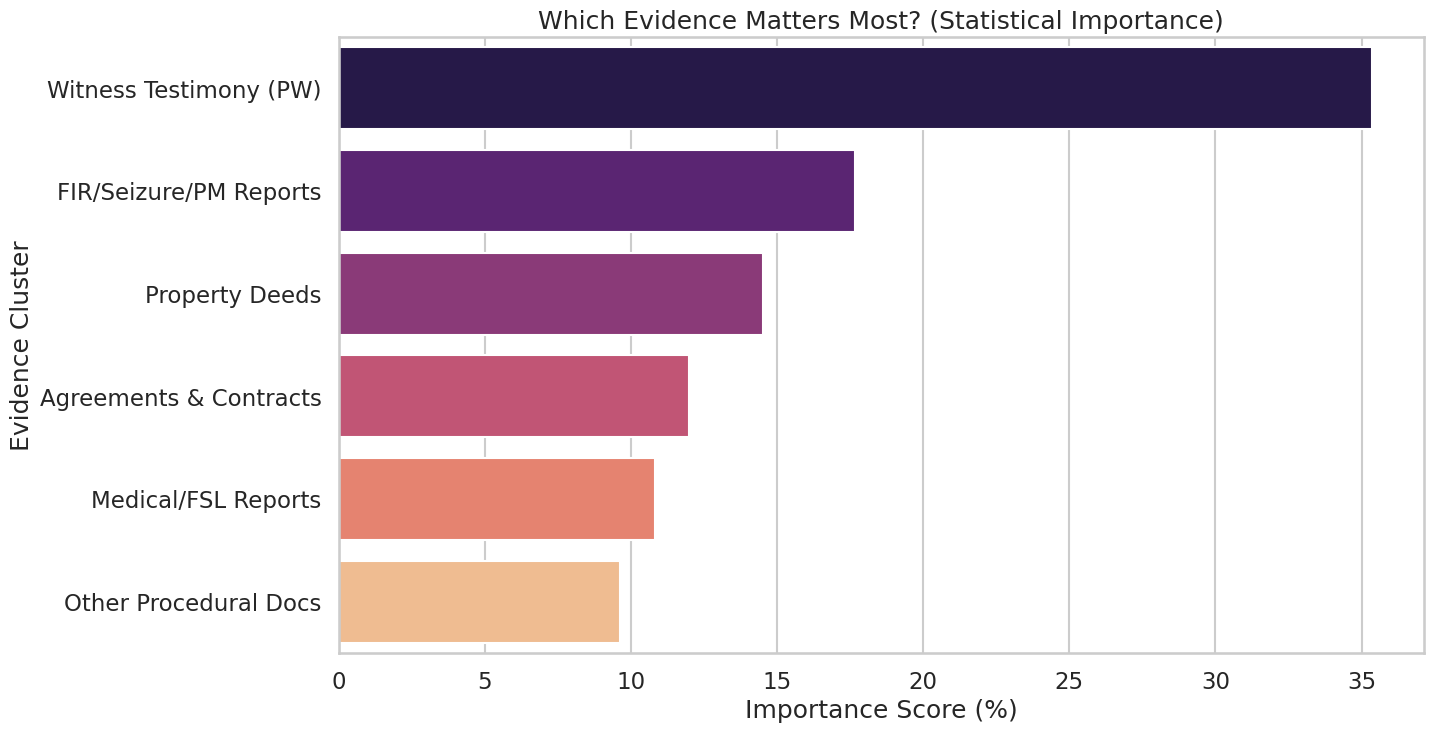

In [ ]:
with open(f'{RESULTS_DIR}/causal_ranking.json', 'r') as f:
    ranking = json.load(f)
rank_df = pd.DataFrame(ranking)
sns.barplot(data=rank_df, x='Importance Score (%)', y='Evidence Cluster', palette='magma')
plt.title('Which Evidence Matters Most? (Statistical Importance)')
plt.show()

## ⚖️ Section 3: Statute-Specific Importance (Criminal vs Civil)
Does the rulebook change? We compare the importance of evidence in Criminal vs. Civil contexts.

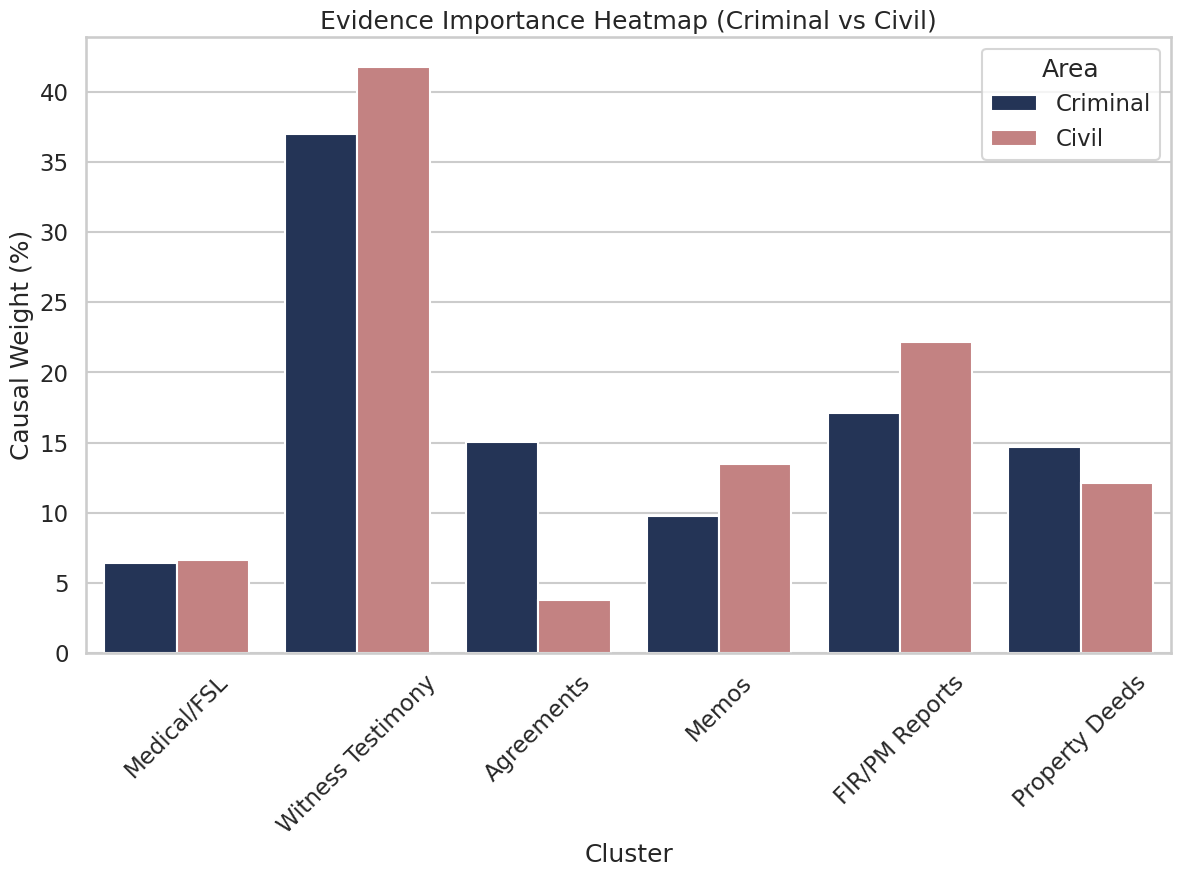

In [ ]:
with open(f'{RESULTS_DIR}/legal_area_comparison.json', 'r') as f:
    comparison = json.load(f)
    
comp_data = []
for area, weights in comparison.items():
    for cluster, val in weights.items():
        comp_data.append({'Area': area.capitalize(), 'Cluster': cluster_names.get(cluster, cluster), 'Importance': val*100})

df_comp = pd.DataFrame(comp_data)
sns.move_legend(sns.barplot(data=df_comp, x='Cluster', y='Importance', hue='Area', palette=['#1C315E', '#CE7777']), "upper right")
plt.title('Evidence Importance Heatmap (Criminal vs Civil)')
plt.xticks(rotation=45)
plt.ylabel('Causal Weight (%)')
plt.show()

## 🤝 Section 4: Evidence Co-occurrence Matrix (Synergy)
Certain pieces of evidence are rarely found alone. This heatmap shows the 'Synergies'—clusters that tend to appear together.

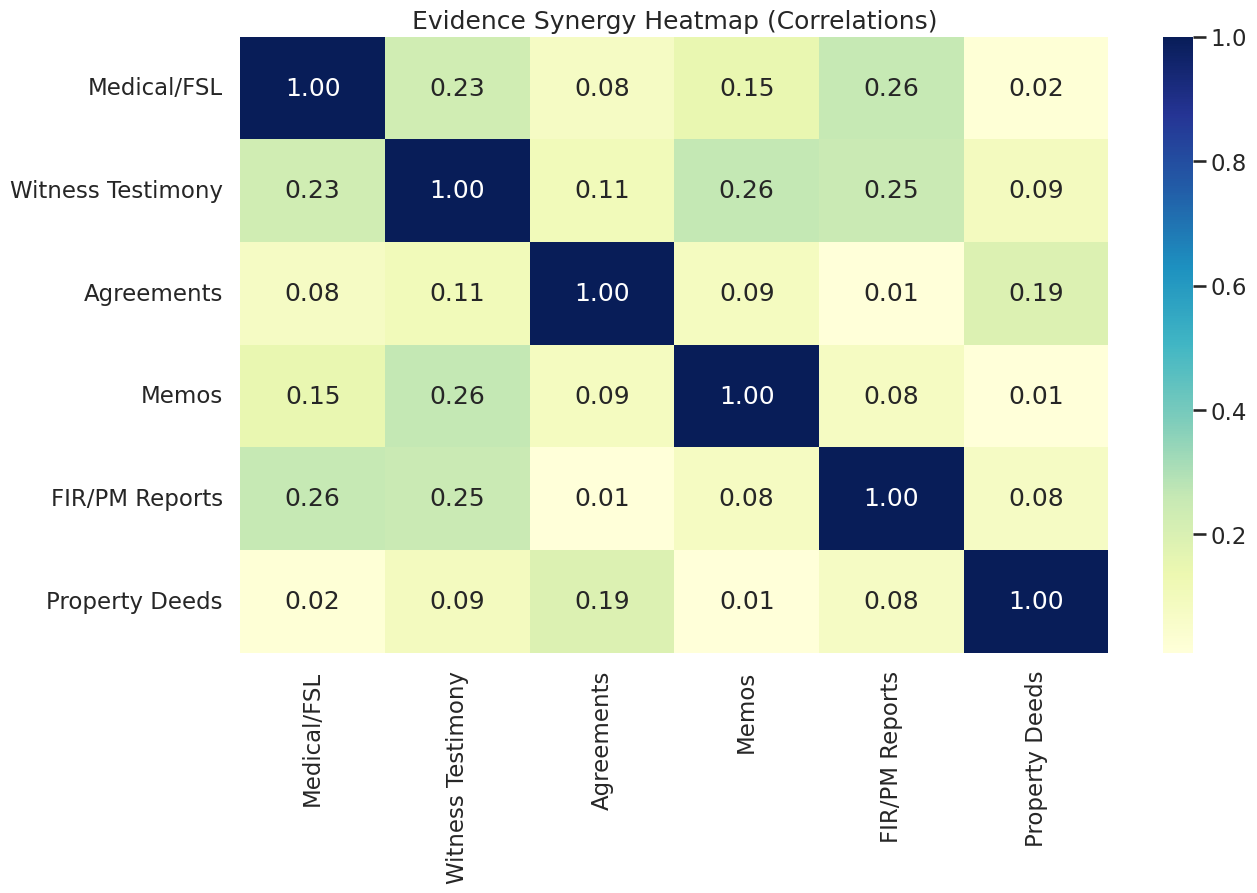

In [ ]:
matrix_df = pd.read_csv(f'{RESULTS_DIR}/case_evidence_matrix.csv')
cols = [c for c in matrix_df.columns if c.startswith('cluster_')]
corr = matrix_df[cols].corr()
corr.columns = [cluster_names.get(c) for c in corr.columns]
corr.index = [cluster_names.get(c) for c in corr.index]

sns.heatmap(corr, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Evidence Synergy Heatmap (Correlations)')
plt.show()

## 🛰️ Section 5: The Recommendation Probe (Live Match)
Simulating the retrieval of similar successful 'peers' for our first Weak Case specimen.

In [ ]:
index = faiss.read_index(f'{RESULTS_DIR}/legal_fact_index.faiss')
with open(f'{RESULTS_DIR}/case_indices.json', 'r') as f:
    case_ids = json.load(f)
failed_ids = [c['case_id'] for c in weak_cases]

test_id = failed_ids[0]
q_idx = case_ids.index(test_id)
q_vec = index.reconstruct(q_idx).reshape(1, -1)
D, I = index.search(q_vec, 15)

success_peers = [case_ids[idx] for idx in I[0] if case_ids[idx] not in failed_ids][:5]
q_row = matrix_df[matrix_df['case_id'] == test_id].iloc[0]
p_rows = matrix_df[matrix_df['case_id'].isin(success_peers)]

print(f"📌 Deep Diagnostic for Weak Case: {test_id}")
diag = []
for c in cols:
    diag.append({'Evidence Type': cluster_names.get(c), 'Current Status': '✅' if q_row[c]==1 else '❌', 'Peer Reliance (%)': f'{p_rows[c].mean()*100:.1g}%' })
pd.DataFrame(diag)

📌 Deep Diagnostic for Weak Case: sikkim_2025_94532254


,Evidence Type,Current Status,Peer Reliance (%)
0,Medical/FSL,❌,4e+01%
1,Witness Testimony,❌,0%
2,Agreements,✅,0%
3,Memos,❌,0%
4,FIR/PM Reports,✅,0%
5,Property Deeds,❌,0%
